# Local projections: dynamic causal effects

**How does an economic shock propagate through the macroeconomy over subsequent years, and does its transmission intensify during recessions relative to economic expansions?**
Jordà (2005) local projections answer this with one regression per horizon —
robust to dynamic misspecification and trivially made *state-dependent*. We
plant a synthetic shock whose effect is stronger in recessions and recover
both the linear and the regime-specific impulse responses with `puremacro.lp`.

## The method in math

To trace the dynamic causal effect of a shock $s_t$ on an outcome $y$, Jordà
(2005) runs **one regression per horizon** $h$, projecting the future outcome's
cumulative change since $t-1$ onto today's shock:
$$ y_{t+h} - y_{t-1} = \alpha_h + \beta_h\, s_t + \gamma_h' x_t + e_{t+h}, \qquad h = 0, 1, \dots, H. $$
The impulse response *is* the sequence of slope coefficients $\{\beta_h\}_{h=0}^{H}$,
read off horizon-by-horizon — no VAR to invert and iterate forward. The controls
$x_t$ (here lags of $y$ and $s$) absorb predictable dynamics so that $\beta_h$ isolates
the effect of the shock.

**Inference.** Stacking horizons means the residual $e_{t+h}$ overlaps its own future:
$e_{t+h}$ and $e_{t+1+h}$ share $h$ periods of innovations, so they are serially
correlated *by construction*. OLS slopes are still consistent, but their textbook
standard errors are wrong. We therefore use **HAC (Newey–West)** standard errors with a
Bartlett kernel and truncation lag $h+1$, and report bands
$\beta_h \pm z_{1-\alpha/2}\, \mathrm{se}(\beta_h)$. The truncation lag is a rule of thumb,
not a published recommendation: the $h$-step residual is serially correlated up to order
$h$, so the kernel must reach at least that far.

**State dependence.** Because each horizon is its own regression, nonlinearity slots in
for free. Interact the shock with a state indicator $I_t$ (e.g. $1$ in recessions) to get
regime-specific responses in a single equation:
$$ y_{t+h} = I_t\big(\alpha_h^{R} + \beta_h^{R} s_t\big) + (1-I_t)\big(\alpha_h^{E} + \beta_h^{E} s_t\big) + \gamma_h' x_t + e_{t+h}, $$
delivering a recession IRF $\{\beta_h^{R}\}$ and an expansion IRF $\{\beta_h^{E}\}$, each with
its own HAC band.

### Baseline Parameterization

| Symbol | Economic / Econometric Role | Baseline Setting | Units |
|---|---|---|---|
| $s_t$ | Structural exogenous policy shock | Synthetic i.i.d. | Standard deviation units ($\sigma$) |
| $y_t$ | Macroeconomic outcome variable | Persistent AR(1) | Index points |
| $I_t$ | Binary recession state indicator | Threshold on latent cycle ($< 35\%$) | Binary dummy $\{0, 1\}$ |
| $h$ | Projection impulse horizon | $0, 1, \dots, 16$ | Months |
| $P$ | Lag length of control variables | $2$ | Lags (months) |
| $\alpha$ | Confidence interval significance level | $0.10$ ($90\%$ confidence) | Probability tail mass |
| $M$ | Newey-West HAC lag truncation bandwidth | $h + 1$ | Lags (months) |
| $\beta_h^R, \beta_h^E$ | Regime-specific impulse response coefficients | True $\beta^R = -0.90, \beta^E = -0.25$ | Response per unit shock |

**Intuition.** Local projections estimate each horizon *separately*, so — unlike the SVAR
of Notebook 6, which imposes one parametric law of motion and iterates it forward — a
misspecified short-run dynamic does not contaminate the long-horizon response, and a
state split is just an interaction term rather than a whole second model. The price is
*efficiency*: throwing away the cross-horizon restrictions makes the estimates noisier,
especially far out, where overlapping windows shrink the effective sample and the HAC
bands fan open. LP buys robustness and flexibility with variance; the SVAR buys precision
with structure.

### Seminal Literature Citations

- Jordà, Ò. (2005). Estimation and inference of impulse responses by local projections. *American Economic Review*, 95(1), 161–182.
- Montiel Olea, J. L., & Plagborg-Møller, M. (2021). Local projection inference is simpler and more robust than you think. *Econometrica*, 89(4), 1789–1823.
- Newey, W. K., & West, K. D. (1987). A simple, positive semi-definite, heteroskedasticity and autocorrelation consistent covariance matrix. *Econometrica*, 55(3), 703–708.
- Plagborg-Møller, M., & Wolf, C. K. (2021). Local projections and VARs estimate the same impulse responses. *Econometrica*, 89(2), 955–980.
- Ramey, V. A., & Zubairy, S. (2018). Government spending multipliers in good times and in bad: Evidence from US historical data. *Journal of Political Economy*, 126(2), 850–901.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

from puremacro.lp.jorda import lp_hac
from puremacro.lp.state_dep import lp_state_dep

# Pyodide contract: after importing the functions we use, no forbidden module
# should have been pulled in. Both LP paths go through the pure-numpy ols_hac.
_bad = [m for m in ("statsmodels", "linearmodels", "arch", "bs4", "requests", "numba")
        if m in sys.modules]
assert _bad == [], f"forbidden modules imported: {_bad}"

Matplotlib is building the font cache; this may take a moment.


## 1. A synthetic shock with state-dependent propagation
A unit i.i.d. shock hits an outcome whose impact is *stronger in recessions*.
The recession dummy is carved from a persistent latent business-cycle factor.

In [2]:
rng = np.random.default_rng(20240529)
T = 360

x = rng.standard_normal(T)                       # identified structural shock
g = np.zeros(T)                                  # persistent business-cycle factor
for t in range(1, T):
    g[t] = 0.85 * g[t - 1] + rng.standard_normal() * 0.5
recession = (g < np.quantile(g, 0.35)).astype(float)   # binary state dummy

beta_exp, beta_rec = -0.25, -0.90                # impact in expansion vs recession
y = np.zeros(T)
for t in range(1, T):
    impact = beta_rec if recession[t] else beta_exp
    y[t] = (0.55 * y[t - 1]
            + impact * x[t - 1]
            + 0.30 * impact * x[t]
            + rng.standard_normal() * 0.35)

df = pd.DataFrame(
    {"y": y, "shock": x, "recession": recession},
    index=pd.date_range("1985-01-01", periods=T, freq="MS"),
)
print(f"recession sample share = {df['recession'].mean():.2f}")

H = 16
horizons = range(0, H + 1)

recession sample share = 0.35


## 2. Linear LP-HAC IRF
`lp_hac` regresses `y_{t+h} - y_{t-1}` on the shock plus lags, with
Newey-West HAC SE (bandwidth h+1) and 90% bands.

In [3]:
lin = lp_hac(df, y="y", x="shock", horizons=horizons, n_lags=2, alpha=0.10)
print(lin.head().round(3).to_string(index=False))

# The planted average response: the shock is independent of the state, so the linear LP
# estimates the state-average of the DGP's impulse response, with b_bar the mean impact.
b_bar = df["recession"].mean() * beta_rec + (1 - df["recession"].mean()) * beta_exp
psi_bar = np.r_[0.3 * b_bar, (1 + 0.55 * 0.3) * b_bar * 0.55 ** np.arange(H)]
covered = (lin["lo"].values <= psi_bar) & (psi_bar <= lin["hi"].values)
print(f"planted average IRF: h=0 {psi_bar[0]:+.3f}, h=1 {psi_bar[1]:+.3f}; "
      f"90% bands containing it: {int(covered.sum())} of {H + 1} horizons")
print(f"se: {lin['se'].iloc[0]:.3f} at h=0, {lin['se'].iloc[1:13].min():.3f}-"
      f"{lin['se'].iloc[1:13].max():.3f} at h=1-12, {lin['se'].iloc[13:].min():.3f}-"
      f"{lin['se'].iloc[13:].max():.3f} at h=13-16")

# Bands present, finite, and correctly ordered.
assert set(lin.columns) >= {"h", "beta", "se", "t", "lo", "hi"}
assert np.all(np.isfinite(lin[["beta", "se", "lo", "hi"]].values))
assert np.all(lin["se"].values > 0)
assert np.all(lin["lo"].values <= lin["beta"].values + 1e-9)
assert np.all(lin["beta"].values <= lin["hi"].values + 1e-9)
z95 = 1.6448536269514722                          # z_{0.95} for the 90% band
assert np.allclose(lin["hi"] - lin["lo"], 2 * z95 * lin["se"], atol=1e-6)

 h   beta    se       t     lo     hi
 0 -0.126 0.026  -4.819 -0.169 -0.083
 1 -0.569 0.044 -13.012 -0.641 -0.497
 2 -0.245 0.047  -5.161 -0.323 -0.167
 3 -0.160 0.043  -3.768 -0.230 -0.090
 4 -0.146 0.039  -3.728 -0.210 -0.081
planted average IRF: h=0 -0.143, h=1 -0.556; 90% bands containing it: 16 of 17 horizons
se: 0.026 at h=0, 0.034-0.047 at h=1-12, 0.049-0.055 at h=13-16


**Read the output.** Each row is one horizon's regression: `beta` is $\beta_h$, the
response of $y$ to a unit shock $h$ months out, and `[lo, hi]` is its 90% HAC band. The
estimate is −0.126 on impact and reaches its trough, −0.569, at $h=1$, because the DGP's
main effect enters through $x_{t-1}$; after that it decays toward zero at roughly the AR
rate 0.55. The shock is independent of the state, so the linear LP targets the
state-average response: the planted values are −0.143 on impact and −0.556 at $h=1$, and
the 90% bands contain the planted path at 16 of the 17 horizons. That is what pointwise
90% bands should do in one sample; the second exercise below checks it across many. The
standard errors show the efficiency cost of estimating each horizon alone: 0.026 on
impact, 0.034–0.047 at $h=1$–12 and 0.049–0.055 at $h=13$–16, as the HAC truncation lag
grows and the overlapping-window sample shrinks. The last `assert` is the band's
*definition*, width $=2 z_{0.95}\,\mathrm{se}$: the confidence level changes only that
multiplier, never the point estimate.

## 3. State-dependent IRFs: recession vs expansion
`lp_state_dep` with `transition="threshold"` splits the shock into a
high-state (recession) and low-state (expansion) interaction and returns
separate coefficients and HAC bands for each regime.

In [4]:
sd = lp_state_dep(df, y="y", x="shock", state="recession",
                  horizons=horizons, n_lags=2,
                  transition="threshold", alpha=0.10)
print(sd[["h", "beta_H", "beta_L"]].head().round(3).to_string(index=False))

assert {"beta_H", "se_H", "lo_H", "hi_H",
        "beta_L", "se_L", "lo_L", "hi_L"}.issubset(sd.columns)
assert np.all(np.isfinite(sd[["beta_H", "beta_L", "se_H", "se_L"]].values))
assert np.all(sd["lo_H"].values <= sd["hi_H"].values)
assert np.all(sd["lo_L"].values <= sd["hi_L"].values)

peak_H = sd["beta_H"].min()        # recession regime (state dummy = 1)
peak_L = sd["beta_L"].min()        # expansion regime
print(f"peak recession beta_H = {peak_H:.3f}   peak expansion beta_L = {peak_L:.3f}   "
      f"ratio {peak_H / peak_L:.1f}")
assert peak_H < peak_L - 0.10, (peak_H, peak_L)        # recession bites harder
gap = sd["hi_H"].values < sd["lo_L"].values            # H-band entirely below L-band
print(f"horizons with non-overlapping regime bands: {int(gap.sum())}")
assert gap.any(), "expected at least one horizon where the regimes separate"

 h  beta_H  beta_L
 0  -0.210  -0.071
 1  -0.832  -0.398
 2  -0.341  -0.182
 3  -0.244  -0.105
 4  -0.210  -0.103
peak recession beta_H = -0.832   peak expansion beta_L = -0.398   ratio 2.1
horizons with non-overlapping regime bands: 2


**Read the output.** Now there are *two* impulse responses from a single regression.
`beta_H` is the recession response (high state, $I_t=1$), `beta_L` the expansion response.
Both are negative, but the recession trough is far deeper: −0.832 against −0.398, a ratio
of 2.1, where the DGP planted impact coefficients $\beta^{R}=-0.90$ and $\beta^{E}=-0.25$.
The economically interesting object is the *gap*: at the 2
horizons counted above, the recession 90% band sits *entirely below* the expansion band
(`hi_H < lo_L`), so the difference is not just a point estimate — it survives HAC
inference. This is the local-projection payoff: a state-dependent IRF, with regime-specific
uncertainty bands, from one interacted regression rather than two separate models. (The
bands are *per regime*; a formal test of $\beta_h^{R}=\beta_h^{E}$ would use their joint
covariance — non-overlap is a sufficient, conservative signal.)

### Hero figure — linear LP-HAC IRF with 90% bands

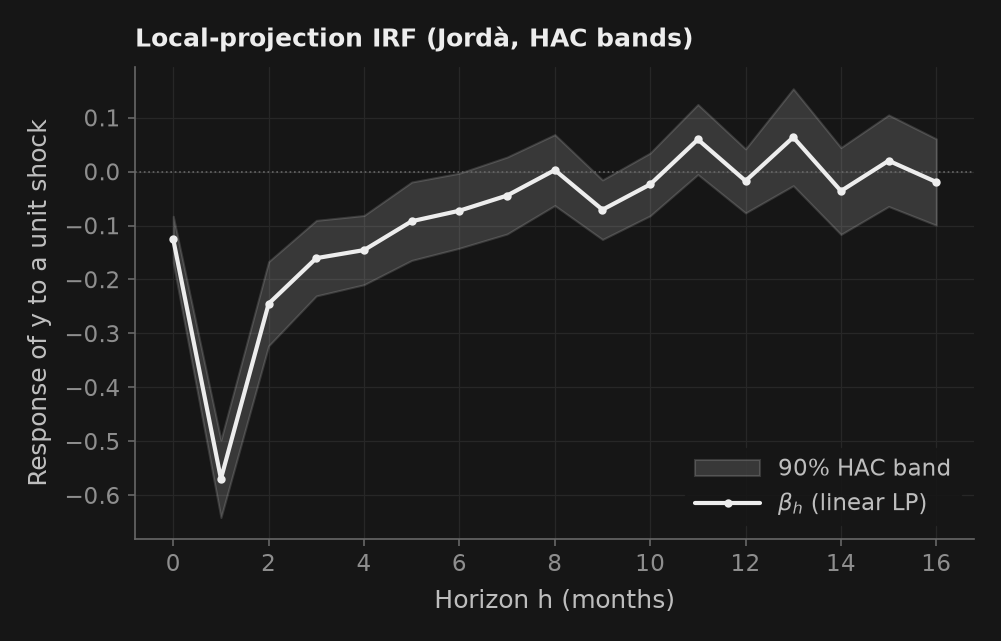

In [5]:
cols = _nbstyle.palette(3)
fig, ax = _nbstyle.figura()
ax.axhline(0.0, color=_nbstyle.SPINE, linewidth=0.8, linestyle=":")
ax.fill_between(lin["h"], lin["lo"], lin["hi"], color=_nbstyle.BANDA, label="90% HAC band")
ax.plot(lin["h"], lin["beta"], color=cols[0], marker="o", markersize=3,
        label=r"$\beta_h$ (linear LP)")
ax.set_xlabel("Horizon h (months)")
ax.set_ylabel("Response of y to a unit shock")
ax.set_title("Local-projection IRF (Jordà, HAC bands)")
ax.legend(loc="lower right")

### Supporting — state-dependent IRFs
The recession response (solid) is markedly deeper than the expansion
response (dashed); shaded regions are the per-regime 90% HAC bands.

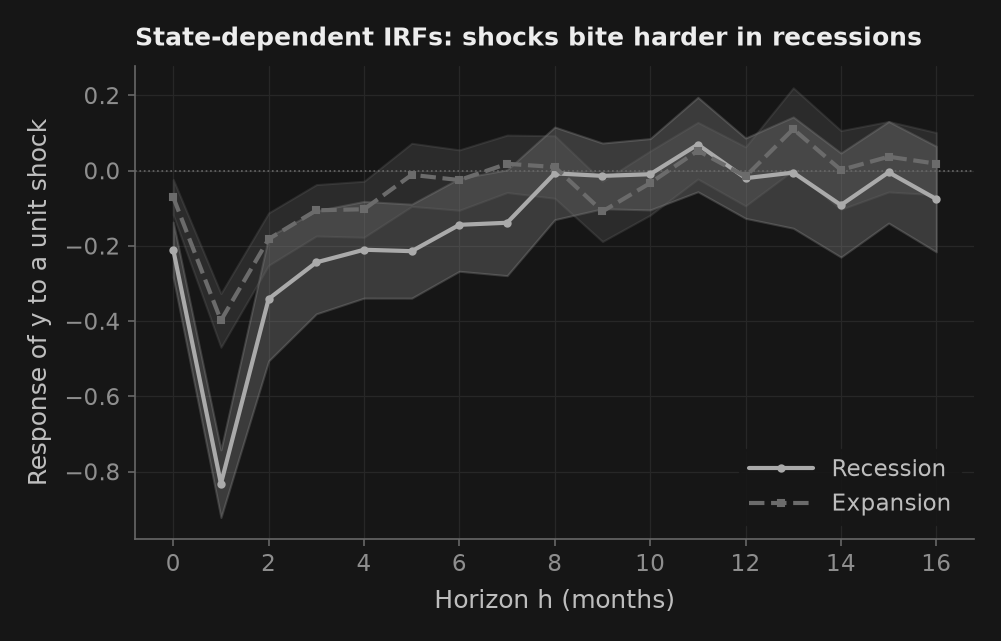

In [6]:
fig, ax = _nbstyle.figura()
ax.axhline(0.0, color=_nbstyle.SPINE, linewidth=0.8, linestyle=":")
ax.fill_between(sd["h"], sd["lo_H"], sd["hi_H"], color=cols[1], alpha=0.25)
ax.fill_between(sd["h"], sd["lo_L"], sd["hi_L"], color=cols[2], alpha=0.25)
ax.plot(sd["h"], sd["beta_H"], color=cols[1], marker="o", markersize=3,
        label="Recession")
ax.plot(sd["h"], sd["beta_L"], color=cols[2], marker="s", markersize=3,
        linestyle="--", label="Expansion")
ax.set_xlabel("Horizon h (months)")
ax.set_ylabel("Response of y to a unit shock")
ax.set_title("State-dependent IRFs: shocks bite harder in recessions")
ax.legend(loc="lower right")

### Supporting — the synthetic series and the state

Text(0.0, 1.0, 'State frequencies')

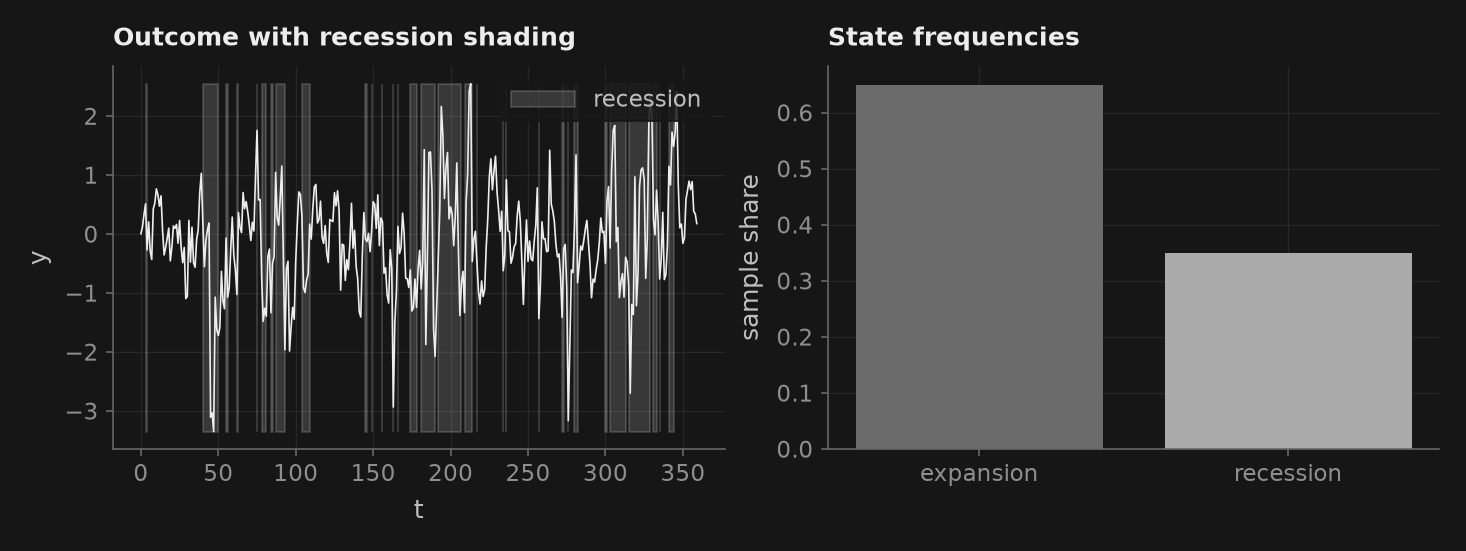

In [7]:
fig, (axL, axR) = _nbstyle.figura(1, 2, ancho=9.5, alto=3.4)
t_idx = np.arange(T)
rec = df["recession"].values
axL.plot(t_idx, df["y"].values, color=_nbstyle.TINTA, linewidth=0.8)
axL.fill_between(t_idx, df["y"].min(), df["y"].max(), where=rec > 0,
                 color=_nbstyle.BANDA, step="mid", label="recession")
axL.set_xlabel("t"); axL.set_ylabel("y")
axL.set_title("Outcome with recession shading"); axL.legend(loc="upper right")
axR.bar(["expansion", "recession"], [(1 - rec).mean(), rec.mean()],
        color=[cols[2], cols[1]])
axR.set_ylabel("sample share"); axR.set_title("State frequencies")

## Your turn — grade the local projections against a planted truth

Four exercises, from basic to stretch. Each cell runs as committed. Change the knob
marked `# ←` within its advertised range, predict the result before you run it, and let
the asserts grade the estimators against the truth planted in the simulation.

### 1. Basic — smooth LP nests Jordà: $\lambda = 0$ switches the penalty off

Barnichon–Brownlees (2019) smooth local projections write $\beta_h = \sum_k b_k(h)\,\theta_k$
on a cubic B-spline basis, fit all horizons jointly, and penalize
$\lambda\,\theta' P_d\,\theta$, where $P_d$ is a $d$-th difference roughness penalty on the
spline coefficients. With `n_knots = H - 3` the basis has $H+1$ functions, one per horizon.
Predict three things first: (a) what the $\lambda = 0$ fit must equal; (b) its effective
degrees of freedom as $\lambda \to \infty$ (what is the null space of a $d$-th difference
penalty?); (c) whether the GCV-selected fit lands between the two limits, both in degrees
of freedom and in roughness.

In [8]:
from puremacro.lp.smooth import lp_smooth

# ← change this: order d of the roughness penalty (advertised range: 1, 2 or 3)
your_order = 2
full = dict(y="y", x="shock", horizons=horizons, n_lags=2, n_knots=H - 3)
s_zero = lp_smooth(df, **full, lam=0.0)
s_inf = lp_smooth(df, **full, lam=1e12, penalty_order=your_order)
s_gcv = lp_smooth(df, **full, selection="gcv")
rough = lambda b: float(np.sum(np.diff(np.asarray(b), 2) ** 2))   # sum of squared 2nd differences
print(f"lambda=0: max |beta_smooth - beta_Jorda| = "
      f"{np.max(np.abs(s_zero['beta'].values - lin['beta'].values)):.1e}")
print(f"effective df: lambda=0 -> {s_zero.df_lambda:.2f} | GCV lambda={s_gcv.optimal_lambda:.3g} -> "
      f"{s_gcv.df_lambda:.2f} | lambda=inf, order {your_order} -> {s_inf.df_lambda:.3f}")
print(f"roughness: Jorda {rough(lin['beta']):.4f} | GCV-smooth {rough(s_gcv['beta']):.4f}")

assert np.allclose(s_zero["beta"].values, lin["beta"].values, atol=1e-10)   # lambda = 0 is Jorda
assert abs(s_inf.df_lambda - your_order) < 1e-3     # the penalty's null space has dimension d
assert 2.0 < s_gcv.df_lambda < H + 1                # GCV shrinks, but not all the way
assert rough(s_gcv["beta"]) < rough(lin["beta"])    # and the smoothed IRF is less rough

lambda=0: max |beta_smooth - beta_Jorda| = 4.4e-16
effective df: lambda=0 -> 17.00 | GCV lambda=6.92 -> 11.93 | lambda=inf, order 2 -> 2.000
roughness: Jorda 0.8028 | GCV-smooth 0.4396


**Prompt.** Set `your_order = 1` and predict the limiting degrees of freedom before you
run it. Smoothing is shrinkage toward the penalty's null space: a flat IRF for $d = 1$,
and for $d = 2$ a curve whose spline coefficients lie on a line. Why is that $d = 2$ limit
close to, but not exactly, a straight line in $h$? (Hint: the boundary knots are clamped.)

### 2. Intermediate — do 90% LP bands cover 90% of the time?

A 90% band is a promise about repeated samples: across many samples it should contain the
true $\beta_h$ 90% of the time. Test the promise where you know the truth. The DGP reuses
section 1's loop with a single impact $b = -0.5$ and no recession split,
$y_t = \phi\, y_{t-1} + b\, x_{t-1} + 0.3\, b\, x_t + 0.35\, e_t$ with $T = 360$, over
$R = 200$ replications (seed $1000 + r$; draw $x$, then $e$). Derive the true IRF by hand
first: $\psi_0 = 0.3 b$, $\psi_1 = \phi\psi_0 + b$, $\psi_h = \phi\,\psi_{h-1}$. (`lp_hac`'s
outcome is $y_{t+h} - y_{t-1}$, but its slope on $x_t$ is the same because $y_{t-1}$ is
already a control.) Predict: will coverage be exactly 0.90 at every horizon?

The cell also runs `la_lp`, the lag-augmented LP of Montiel Olea and Plagborg-Møller
(2021), on the same draws: two lags plus one augmentation lag, with Eicker-Huber-White
standard errors and no HAC correction.

In [9]:
import math
from puremacro.lp.la_lp import la_lp

# ← change this: persistence phi of y (advertised range 0.0 to 0.7)
phi_mc = 0.55
R, T_mc, b_mc = 200, 360, -0.5
psi = np.empty(H + 1)
psi[0] = 0.3 * b_mc
psi[1] = phi_mc * psi[0] + b_mc
for h in range(2, H + 1):
    psi[h] = phi_mc * psi[h - 1]

betas, ses = np.empty((R, H + 1)), np.empty((R, H + 1))
hit, hit_la = np.empty((R, H + 1), bool), np.empty((R, H + 1), bool)
width, width_la = np.empty((R, H + 1)), np.empty((R, H + 1))
for r in range(R):
    g_r = np.random.default_rng(1000 + r)
    x_r = g_r.standard_normal(T_mc)
    e_r = g_r.standard_normal(T_mc)
    y_r = np.zeros(T_mc)
    for t in range(1, T_mc):
        y_r[t] = phi_mc * y_r[t - 1] + b_mc * x_r[t - 1] + 0.3 * b_mc * x_r[t] + 0.35 * e_r[t]
    d_r = pd.DataFrame({"y": y_r, "shock": x_r})
    res = lp_hac(d_r, y="y", x="shock", horizons=horizons, n_lags=2, alpha=0.10)
    la = la_lp(d_r, y="y", x="shock", horizons=horizons, n_lags=2, alpha=0.10)
    betas[r], ses[r] = res["beta"].values, res["se"].values
    hit[r] = (res["lo"].values <= psi) & (psi <= res["hi"].values)
    hit_la[r] = (la["lo"].values <= psi) & (psi <= la["hi"].values)
    width[r], width_la[r] = (res["hi"] - res["lo"]).values, (la["hi"] - la["lo"]).values

cov, cov_la = hit.mean(0), hit_la.mean(0)
ratio = ses.mean(0) / betas.std(0)                  # average SE over the true sampling s.d.
pred = math.erf(z95 * ratio.mean() / math.sqrt(2))  # coverage of a normal band with that SE ratio
bias_sd = (betas.mean(0) - psi) / betas.std(0)
print("lp_hac coverage by h:", np.array2string(cov, precision=3))
print(f"lp_hac: mean coverage {cov.mean():.3f} (Monte Carlo s.e. of one horizon "
      f"{math.sqrt(0.09 / R):.3f}); se/sd {ratio.min():.2f}-{ratio.max():.2f}, mean "
      f"{ratio.mean():.3f}; erf prediction {pred:.3f} (gap {cov.mean() - pred:+.4f}); "
      f"max |bias|/sd {np.abs(bias_sd).max():.2f}")
print(f"la_lp:  mean coverage {cov_la.mean():.3f} (range {cov_la.min():.3f}-{cov_la.max():.3f}) "
      f"with p_aug = {la.attrs['p_aug']}; band width la_lp / lp_hac = "
      f"{(width_la.mean(0) / width.mean(0)).mean():.3f}")

assert 0.80 < cov.mean() < 0.95 and 0.80 < cov_la.mean() < 0.95
assert cov[0] >= 0.85 and cov[1] >= 0.85            # also checks the psi_0 and psi_1 derivation
assert abs(cov.mean() - pred) < 0.015               # the SE ratio explains the shortfall

lp_hac coverage by h: [0.915 0.9   0.885 0.89  0.865 0.855 0.905 0.88  0.87  0.84  0.855 0.87
 0.86  0.905 0.89  0.88  0.85 ]
lp_hac: mean coverage 0.877 (Monte Carlo s.e. of one horizon 0.021); se/sd 0.89-1.03, mean 0.955; erf prediction 0.884 (gap -0.0064); max |bias|/sd 0.17
la_lp:  mean coverage 0.884 (range 0.845-0.935) with p_aug = 3; band width la_lp / lp_hac = 1.023


**Prompts.** (a) Is the shortfall from 0.90 larger than Monte Carlo noise? The `erf` line
is the coverage of a normal band whose standard error is off by the printed average
ratio: use it to say whether the bands under-cover because they are too narrow or because
the estimates are biased. (b) Compare the `la_lp` line. Are its bands wider, and do they
cover better? The shock is i.i.d. and two lags already capture the dynamics, so what does
the extra lag buy here, and what does it cost? Then rerun `la_lp` with `extra_lags=H`,
the library default before the fix (puremacro 4.3.0 and earlier: $2 + 16 = 18$ lags at
every horizon), and predict first whether more lags help. (c) *Stretch*: set
`phi_mc = 0.95`, outside the advertised range, and predict which assert fails. Compute
`bias_sd[8:].mean()` at 0.95 and at 0.55: does the long-horizon bias grow, and can the
standard-error ratio alone still explain the coverage?

### 3. Intermediate — a sign asymmetry, and the average a linear LP reports instead

Plant a sign asymmetry, in the spirit of the "pushing on a string" idea that tightening
bites harder than easing:
$y_t = 0.5\, y_{t-1} + a_+ \max(x_{t-1}, 0) + a_- \min(x_{t-1}, 0) + e_t$ with $a_+ = 1.0$.
`lp_asymmetric` splits $x_t$ into its positive and negative parts; the linear `lp_hac`
runs on the same data. Derive the true responses first: 0 at $h = 0$ and
$a\, 0.5^{h-1}$ for $h \ge 1$. Then predict where the linear LP lands. It is neither
response but a weighted average, $w\, a_+ + (1 - w)\, a_-$ with
$w = \mathrm{Cov}(x, x^+)/\mathrm{Var}(x)$ and $x^+ = \max(x, 0)$.

In [10]:
from puremacro.lp.asymmetric import lp_asymmetric

# ← change this: shock distribution, "normal" or "skewed" (right-skewed with mean zero)
shock_dist = "normal"
# ← change this: planted response to negative shocks, 0.3 (asymmetric) or 1.0 (= a_pos)
a_neg = 0.3
a_pos = 1.0
rng_a = np.random.default_rng(7)
Ta = 500
xa = rng_a.standard_normal(Ta) if shock_dist == "normal" else rng_a.exponential(1.0, Ta) - 1.0
ea = 0.5 * rng_a.standard_normal(Ta)
ya = np.zeros(Ta)
for t in range(1, Ta):
    ya[t] = 0.5 * ya[t - 1] + a_pos * max(xa[t - 1], 0.0) + a_neg * min(xa[t - 1], 0.0) + ea[t]
dfa = pd.DataFrame({"y": ya, "shock": xa})
asy = lp_asymmetric(dfa, y="y", x="shock", horizons=range(0, 9), n_lags=2, alpha=0.10)
lin_a = lp_hac(dfa, y="y", x="shock", horizons=range(0, 9), n_lags=2, alpha=0.10)
r1 = asy[asy["h"] == 1].iloc[0]                    # true h=1 responses: a_pos and a_neg
b1, se1 = float(lin_a["beta"].iloc[1]), float(lin_a["se"].iloc[1])
w_pos = np.cov(xa, np.maximum(xa, 0))[0, 1] / np.var(xa, ddof=1)
pred_lin = w_pos * a_pos + (1 - w_pos) * a_neg
separated = bool(r1["hi_neg"] < r1["lo_pos"])
print(f"h=1: beta_pos = {r1['beta_pos']:.3f} (planted {a_pos})  beta_neg = {r1['beta_neg']:.3f} "
      f"(planted {a_neg});  90% bands separated: {separated}")
print(f"h=1: linear LP beta = {b1:.3f}  vs  w*a_pos + (1-w)*a_neg = {pred_lin:.3f} (w = {w_pos:.2f})")

assert abs(r1["beta_pos"] - a_pos) < 3 * r1["se_pos"] and abs(r1["beta_neg"] - a_neg) < 3 * r1["se_neg"]
assert abs(b1 - pred_lin) < 3 * se1                 # the linear LP is the w-weighted average
assert separated == (a_pos - a_neg > 0.5)           # the bands separate when the planted gap is large

h=1: beta_pos = 0.987 (planted 1.0)  beta_neg = 0.318 (planted 0.3);  90% bands separated: True
h=1: linear LP beta = 0.616  vs  w*a_pos + (1-w)*a_neg = 0.612 (w = 0.45)


**Prompts.** (a) Set `a_neg = 1.0`, so there is no asymmetry to find, and predict what
`separated` prints. (b) Switch to `shock_dist = "skewed"`. Predict first how $w$ moves and
where the linear IRF goes with it. The "average effect" a linear LP reports depends on the
shock distribution, not only on the economics.

### 4. Stretch — does smoothing pay? A Monte Carlo bias–variance check on a planted hump

One sample cannot tell how much variance smoothing removes, so run a Monte Carlo. The
planted hump is $y_t = 0.4\, y_{t-1} + \sum_{k=0}^{9} w_k\, x_{t-k} + e_t$ with
$w = (0, .2, .5, .8, 1, 1, .8, .5, .2, 0)$, $x_t$ i.i.d. $N(0, 1)$,
$e_t \sim N(0, \sigma_e^2)$ and $T = 200$. The true IRF follows
$\psi_h = 0.4\, \psi_{h-1} + w_h$, with its peak at $h = 5$. For seeds 0 to 59, estimate
`lp_hac` and `lp_smooth(..., n_knots=4, selection="gcv")` at $h = 0, \dots, 12$ and compare
the summed variance, the summed MSE against $\psi$, the bias at the peak, and the
correlation of the Jordà errors at $h = 5$ and $h = 6$.

In [11]:
# ← change this: noise s.d. sigma_e (advertised range 1.5 to 4.0)
noise_sd = 2.0
w_hump = np.array([0, .2, .5, .8, 1, 1, .8, .5, .2, 0])
Hm, T_sm = 12, 200
psi_h = np.zeros(Hm + 1)
for h in range(Hm + 1):
    psi_h[h] = (0.4 * psi_h[h - 1] if h else 0.0) + (w_hump[h] if h < len(w_hump) else 0.0)
raw, smo = [], []
for s in range(60):
    g_s = np.random.default_rng(s)
    x_s = g_s.standard_normal(T_sm + 20)
    e_s = noise_sd * g_s.standard_normal(T_sm + 20)
    y_s = np.zeros(T_sm + 20)
    for t in range(10, T_sm + 20):                  # 20 burn-in periods are dropped below
        y_s[t] = 0.4 * y_s[t - 1] + w_hump @ x_s[t - np.arange(10)] + e_s[t]
    d_s = pd.DataFrame({"y": y_s[20:], "shock": x_s[20:]})
    raw.append(lp_hac(d_s, y="y", x="shock", horizons=range(Hm + 1), n_lags=2)["beta"].values)
    smo.append(lp_smooth(d_s, y="y", x="shock", horizons=range(Hm + 1), n_lags=2,
                         n_knots=4, selection="gcv")["beta"].values)
raw, smo = np.array(raw), np.array(smo)
var_ratio = smo.var(0).sum() / raw.var(0).sum()
mse_raw, mse_smo = ((raw - psi_h) ** 2).mean(0).sum(), ((smo - psi_h) ** 2).mean(0).sum()
bias5_raw, bias5_smo = raw[:, 5].mean() - psi_h[5], smo[:, 5].mean() - psi_h[5]
corr56 = np.corrcoef(raw[:, 5] - psi_h[5], raw[:, 6] - psi_h[6])[0, 1]
print(f"noise_sd={noise_sd}: var(smooth)/var(Jorda) = {var_ratio:.3f}; "
      f"MSE Jorda {mse_raw:.3f} vs smooth {mse_smo:.3f}")
print(f"peak (h=5, true {psi_h[5]:.3f}) bias: Jorda {bias5_raw:+.3f}, smooth {bias5_smo:+.3f}; "
      f"corr of Jorda errors at h=5,6: {corr56:.2f}")

assert var_ratio < 0.95                             # smoothing removes variance...
assert bias5_smo < bias5_raw                        # ...shaves the peak (bias)...
assert mse_smo < mse_raw                            # ...and wins on MSE at this noise level

noise_sd=2.0: var(smooth)/var(Jorda) = 0.851; MSE Jorda 0.752 vs smooth 0.680
peak (h=5, true 1.565) bias: Jorda -0.013, smooth -0.116; corr of Jorda errors at h=5,6: 0.62


**Prompt.** Set `noise_sd = 0.5`, below the advertised range; it is the noise level of
`puremacro/examples/lp_smooth_demo.py`. Predict which asserts fail before you run it, then
use the printed error correlation to explain why. When the LP errors at adjacent horizons
are almost perfectly correlated, the estimation noise is itself smooth in $h$: a roughness
penalty cannot remove it and only shaves the hump. Smoothing pays when the
horizon-by-horizon errors are less correlated.

**How comprehensive is this?** `puremacro.lp` is a full local-projection toolkit beyond
these estimators: lag-augmented LP, whose Eicker-Huber-White bands stay valid for highly
persistent data and over a wide range of horizons without a HAC correction (`la_lp`,
Montiel Olea–Plagborg-Møller 2021; exercise 2), LP-IV / proxy identification (`lp_iv`,
Stock–Watson 2018), smooth LP (`lp_smooth`, Barnichon–Brownlees 2019; exercises 1 and 4),
sign asymmetry (`lp_asymmetric`; exercise 3), smooth-transition state dependence
(`lp_state_dep` with `transition="logistic"`, its default), quantile LP (`lp_quantile`),
and two-way fixed-effects **panel** variants with Driscoll–Kraay, mean-group, and CCE
standard errors (`panel_lp`, `panel_lp_dk`, `panel_lp_iv`, `mean_group_panel_lp`,
`cce_panel_lp`). The structural alternative — imposing the whole dynamic system rather than
one regression per horizon — is the SVAR of **Notebook 6** (`puremacro.var`). End-to-end
demos live in `puremacro/examples/` (`la_lp_pmw_demo`, whose name is historical,
`lp_smooth_demo`, `lp_asymmetric_tenreyro`, `lp_panel_dk`, `narrative_panel_lp`). Every
estimator here rides the pure-numpy `ols_hac` path or plain least squares, so the notebook
stays Pyodide-clean (no statsmodels).